In [1]:
!pip install mlflow

In [2]:
!pip install dagshub

In [3]:
!pip install ultralytics

In [4]:
!pip install torch

In [5]:
import os
import json
import yaml
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from pathlib import Path

In [6]:
from ultralytics import YOLO
from ultralytics import settings
settings.update({"mlflow": False})

In [7]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

from ultralytics import YOLO
model = YOLO("yolov8l-seg.pt")

2.6.0+cu118
True


In [8]:
# MLflow setup (Dagshub) — never commit tokens. Set in your environment, e.g.:
#   MLFLOW_TRACKING_USERNAME, MLFLOW_TRACKING_PASSWORD (DagsHub token from user settings)
os.environ.setdefault(
    "MLFLOW_TRACKING_URI",
    "https://dagshub.com/sableen-kaur788/AI_Car_Damage_Analyzer.mlflow",
)

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

In [9]:
import os
import shutil
import time
import pandas as pd
from collections import Counter, defaultdict
import mlflow

from ultralytics import YOLO, settings

settings.mlflow = False

In [10]:
from collections import Counter
import os
import pandas as pd

YOLO_DATASET = "/kaggle/input/datasets/sableenkaur/dataset/yolo_dataset"

LABEL_SPLITS = [
    os.path.join(YOLO_DATASET, "labels", "train"),
    os.path.join(YOLO_DATASET, "labels", "val"),
    os.path.join(YOLO_DATASET, "labels", "test")
]

CLASSES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat', 'structural damage']
NUM_CLASSES = len(CLASSES)

counter = Counter()

for label_dir in LABEL_SPLITS:
    for file in os.listdir(label_dir):
        if not file.endswith(".txt"):
            continue

        path = os.path.join(label_dir, file)

        with open(path) as f:
            lines = f.readlines()

            for line in lines:
                cls = int(line.split()[0])
                counter[cls] += 1

counts = [counter[i] for i in range(NUM_CLASSES)]

df = pd.DataFrame({
    "class": CLASSES,
    "count": counts
})

print("📊 Correct Class Distribution:")
display(df)

📊 Correct Class Distribution:


,class,count
0,dent,2557
1,scratch,3597
2,crack,898
3,glass shatter,695
4,lamp broken,704
5,tire flat,320
6,structural damage,62


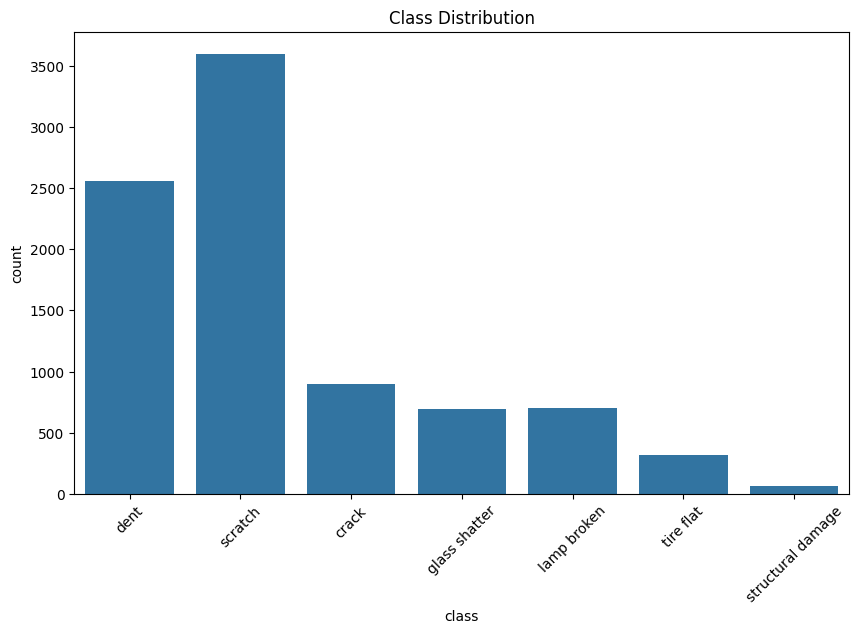

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(x="class",y="count",data=df)

plt.xticks(rotation=45)

plt.title("Class Distribution")

plt.show()

In [12]:
import os
import shutil

# ================== PATHS ==================
DATA_ROOT = "/kaggle/input/datasets/sableenkaur/dataset/yolo_dataset"

IMAGES_DIR = os.path.join(DATA_ROOT, "images/train")
LABELS_DIR = os.path.join(DATA_ROOT, "labels/train")

OUT_DIR = "/kaggle/working/balanced_dataset"
OUT_IMG = os.path.join(OUT_DIR, "images/train")
OUT_LBL = os.path.join(OUT_DIR, "labels/train")

os.makedirs(OUT_IMG, exist_ok=True)
os.makedirs(OUT_LBL, exist_ok=True)

# ================== CONFIG ==================
RARE_CLASSES = [5, 6]   # tire flat, structural damage
DUP_FACTOR = 2          # light oversampling

print("🚀 Creating balanced dataset...")

for file in os.listdir(IMAGES_DIR):
    if not file.endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(IMAGES_DIR, file)
    lbl_path = os.path.join(LABELS_DIR, file.replace(".jpg", ".txt"))

    if not os.path.exists(lbl_path):
        continue

    # Read labels
    with open(lbl_path, "r") as f:
        labels = [int(line.split()[0]) for line in f.readlines()]

    # Count rare class occurrences
    rare_count = sum(1 for c in labels if c in RARE_CLASSES)

    # Copy original once
    shutil.copy(img_path, os.path.join(OUT_IMG, file))
    shutil.copy(lbl_path, os.path.join(OUT_LBL, file.replace(".jpg", ".txt")))

    # Oversample based on rare class presence
    if rare_count > 0:
        for i in range(DUP_FACTOR - 1):  # already copied once
            new_name = file.replace(".jpg", f"_dup{i}.jpg")

            shutil.copy(img_path, os.path.join(OUT_IMG, new_name))
            shutil.copy(lbl_path, os.path.join(OUT_LBL, new_name.replace(".jpg", ".txt")))

print("✅ Balanced dataset created!")

🚀 Creating balanced dataset...
✅ Balanced dataset created!


In [13]:
import os
from collections import Counter
import pandas as pd

LABEL_DIR = "/kaggle/working/balanced_dataset/labels/train"

CLASSES = [
    'dent', 'scratch', 'crack',
    'glass shatter', 'lamp broken',
    'tire flat', 'structural damage'
]

counter = Counter()

for file in os.listdir(LABEL_DIR):
    if not file.endswith(".txt"):
        continue

    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            counter[cls] += 1

df = pd.DataFrame({
    "class": CLASSES,
    "count": [counter[i] for i in range(len(CLASSES))]
})

print(df)

               class  count
0               dent   1876
1            scratch   2613
2              crack    676
3      glass shatter    502
4        lamp broken    504
5          tire flat    452
6  structural damage    112


In [14]:
import os
from collections import Counter
import pandas as pd

def get_counts(label_dir):
    counter = Counter()
    for file in os.listdir(label_dir):
        if not file.endswith(".txt"):
            continue

        with open(os.path.join(label_dir, file)) as f:
            for line in f:
                cls = int(line.split()[0])
                counter[cls] += 1
    return counter

# Paths
original_dir = "/kaggle/input/datasets/sableenkaur/dataset/yolo_dataset/labels/train"
balanced_dir = "/kaggle/working/balanced_dataset/labels/train"

orig = get_counts(original_dir)
bal = get_counts(balanced_dir)

CLASSES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat', 'structural damage']

df_compare = pd.DataFrame({
    "class": CLASSES,
    "before": [orig[i] for i in range(len(CLASSES))],
    "after": [bal[i] for i in range(len(CLASSES))]
})

print("📊 Before vs After:")
display(df_compare)

📊 Before vs After:


,class,before,after
0,dent,1818,1876
1,scratch,2562,2613
2,crack,651,676
3,glass shatter,489,502
4,lamp broken,494,504
5,tire flat,226,452
6,structural damage,56,112


In [15]:
yaml_content = """
path: /kaggle/working/balanced_dataset

train: images/train
val: images/val
test: images/test

nc: 7
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat
  6: structural damage
"""

with open("/kaggle/working/balanced_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml created successfully")

✅ data.yaml created successfully


In [16]:
AUGMENTATION = dict(
    hsv_h=0.012,
    hsv_s=0.7,
    hsv_v=0.5,

    degrees=2.0,
    translate=0.07,
    scale=0.4,
    shear=1.0,
    perspective=0.0005,

    fliplr=0.5,
    flipud=0.0,

    mosaic=0.6,
    mixup=0.15,
    copy_paste=0.65,

    erasing=0.25,
    close_mosaic=20
)

In [17]:
import os
from collections import Counter
import pandas as pd

LABEL_DIR = "/kaggle/working/balanced_dataset/labels/train"

CLASSES = [
    'dent', 'scratch', 'crack',
    'glass shatter', 'lamp broken',
    'tire flat', 'structural damage'
]

counter = Counter()

for file in os.listdir(LABEL_DIR):
    if not file.endswith(".txt"):
        continue

    with open(os.path.join(LABEL_DIR, file), "r") as f:
        for line in f:
            cls = int(line.split()[0])
            counter[cls] += 1

counts = [counter[i] for i in range(len(CLASSES))]

df = pd.DataFrame({
    "class": CLASSES,
    "count": counts
})

print("📊 Balanced Dataset Distribution:")
display(df)

📊 Balanced Dataset Distribution:


,class,count
0,dent,1876
1,scratch,2613
2,crack,676
3,glass shatter,502
4,lamp broken,504
5,tire flat,452
6,structural damage,112


In [18]:
import os

base = "/kaggle/working/balanced_dataset"

for root, dirs, files in os.walk(base):
    print(root)

/kaggle/working/balanced_dataset
/kaggle/working/balanced_dataset/labels
/kaggle/working/balanced_dataset/labels/train
/kaggle/working/balanced_dataset/labels/val
/kaggle/working/balanced_dataset/labels/test
/kaggle/working/balanced_dataset/images
/kaggle/working/balanced_dataset/images/train
/kaggle/working/balanced_dataset/images/val
/kaggle/working/balanced_dataset/images/test


In [19]:
import os
import shutil

# SOURCE (original dataset)
SRC_BASE = "/kaggle/input/datasets/sableenkaur/dataset/yolo_dataset"

# DEST (balanced dataset)
DEST_BASE = "/kaggle/working/balanced_dataset"

# Define splits
splits = ["val", "test"]

for split in splits:
    src_img_dir = os.path.join(SRC_BASE, f"images/{split}")
    src_lbl_dir = os.path.join(SRC_BASE, f"labels/{split}")

    dest_img_dir = os.path.join(DEST_BASE, f"images/{split}")
    dest_lbl_dir = os.path.join(DEST_BASE, f"labels/{split}")

    os.makedirs(dest_img_dir, exist_ok=True)
    os.makedirs(dest_lbl_dir, exist_ok=True)

    # Copy images
    for file in os.listdir(src_img_dir):
        if file.endswith((".jpg", ".png", ".jpeg")):
            shutil.copy(
                os.path.join(src_img_dir, file),
                os.path.join(dest_img_dir, file)
            )

    # Copy labels
    for file in os.listdir(src_lbl_dir):
        if file.endswith(".txt"):
            shutil.copy(
                os.path.join(src_lbl_dir, file),
                os.path.join(dest_lbl_dir, file)
            )

print("✅ Val and Test copied into balanced_dataset")

✅ Val and Test copied into balanced_dataset


In [20]:
import os

base = "/kaggle/working/balanced_dataset"

for root, dirs, files in os.walk(base):
    print(root)

/kaggle/working/balanced_dataset
/kaggle/working/balanced_dataset/labels
/kaggle/working/balanced_dataset/labels/train
/kaggle/working/balanced_dataset/labels/val
/kaggle/working/balanced_dataset/labels/test
/kaggle/working/balanced_dataset/images
/kaggle/working/balanced_dataset/images/train
/kaggle/working/balanced_dataset/images/val
/kaggle/working/balanced_dataset/images/test


In [37]:
!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 \
--index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 83.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 48.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 108.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 3.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 35.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 12.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 \
--index-url https://download.pytorch.org/whl/cu118 

In [38]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla P100-PCIE-16GB


# 80 epochs

In [30]:
# ---------------- DISABLE YOLO INTERNAL MLflow BEFORE IMPORT ----------------
from ultralytics import settings
settings.mlflow = False

# ---------------- IMPORTS ----------------
import os
import shutil
import time
import pandas as pd
import mlflow
from ultralytics import YOLO

# ---------------- MLflow SETUP ----------------
mlflow.set_tracking_uri("https://dagshub.com/sableen-kaur788/AI_Car_Damage_Detector.mlflow")
mlflow.set_experiment("AI_Car_Damage_Detector")

# ---------------- PATHS ----------------
YOLO_DATASET = "/kaggle/working/balanced_dataset"
DATASET_YAML = f"{YOLO_DATASET}/data.yaml"

PROJECT = "/kaggle/working/car_experiment"
RUN_NAME = f"yolo_seg_run_{int(time.time())}"
RUN_DIR = f"{PROJECT}/{RUN_NAME}"

os.makedirs(RUN_DIR, exist_ok=True)

# ---------------- LOAD MODEL ----------------
print("🚀 Starting YOLOv8 Segmentation training...")
model = YOLO("yolov8l-seg.pt")

# ---------------- SAFE CALLBACK ----------------
def on_fit_epoch_end(trainer):
    try:
        epoch = trainer.epoch

        if hasattr(trainer, "validator") and trainer.validator is not None:
            metrics = trainer.validator.metrics

            if hasattr(metrics, "box"):
                box = metrics.box

                if hasattr(box, "mp"):
                    mlflow.log_metric("precision", float(box.mp), step=epoch)
                if hasattr(box, "mr"):
                    mlflow.log_metric("recall", float(box.mr), step=epoch)
                if hasattr(box, "map50"):
                    mlflow.log_metric("mAP50", float(box.map50), step=epoch)
                if hasattr(box, "map"):
                    mlflow.log_metric("mAP50_95", float(box.map), step=epoch)

            if hasattr(metrics, "seg") and metrics.seg is not None:
                seg = metrics.seg

                if hasattr(seg, "mp"):
                    mlflow.log_metric("mask_precision", float(seg.mp), step=epoch)
                if hasattr(seg, "mr"):
                    mlflow.log_metric("mask_recall", float(seg.mr), step=epoch)
                if hasattr(seg, "map50"):
                    mlflow.log_metric("mask_mAP50", float(seg.map50), step=epoch)
                if hasattr(seg, "map"):
                    mlflow.log_metric("mask_mAP50_95", float(seg.map), step=epoch)

    except Exception as e:
        print("Callback logging skipped:", e)

model.add_callback("on_fit_epoch_end", on_fit_epoch_end)

# ---------------- START MLflow RUN ----------------
with mlflow.start_run(run_name=RUN_NAME):

    # -------- LOG PARAMS --------
    mlflow.log_param("model", "yolov8l-seg")
    mlflow.log_param("epochs", 80)   # ✅ changed
    mlflow.log_param("imgsz", 768)
    mlflow.log_param("batch", 6)

    # -------- LOG DATASET YAML --------
    mlflow.log_artifact(DATASET_YAML)

    # ---------------- TRAIN ----------------
    results = model.train(
        data=DATASET_YAML,
        epochs=80,              # ✅ changed
        imgsz=768,
        batch=6,
        project=PROJECT,
        name=RUN_NAME,
        save=True,
        save_period=40          # ✅ changed
    )

    run_dir = results.save_dir

    # ---------------- RESULTS CSV ----------------
    results_csv = os.path.join(run_dir, "results.csv")
    if os.path.exists(results_csv):
        mlflow.log_artifact(results_csv)

    # ---------------- VALIDATION ----------------
    val_metrics = model.val(data=DATASET_YAML)

    val_df = pd.DataFrame([{
        "precision": val_metrics.box.mp,
        "recall": val_metrics.box.mr,
        "mAP50": val_metrics.box.map50,
        "mAP50_95": val_metrics.box.map
    }])

    val_csv = os.path.join(run_dir, "val.csv")
    val_df.to_csv(val_csv, index=False)
    mlflow.log_artifact(val_csv)

    # ---------------- TEST ----------------
    try:
        test_metrics = model.val(data=DATASET_YAML, split="test")

        test_df = pd.DataFrame([{
            "precision": test_metrics.box.mp,
            "recall": test_metrics.box.mr,
            "mAP50": test_metrics.box.map50,
            "mAP50_95": test_metrics.box.map
        }])

        test_csv = os.path.join(run_dir, "test.csv")
        test_df.to_csv(test_csv, index=False)
        mlflow.log_artifact(test_csv)

    except Exception as e:
        print("⚠️ Test split not available:", e)

    # ---------------- PREDICTIONS ----------------
    model.predict(
        source=f"{YOLO_DATASET}/images/val",
        conf=0.25,
        save=True,
        project=run_dir,
        name="sample_predictions"
    )

    pred_dir = os.path.join(run_dir, "sample_predictions")
    if os.path.exists(pred_dir):
        mlflow.log_artifacts(pred_dir)

    # ---------------- SAVE WEIGHTS ----------------
    weights_dir = os.path.join(run_dir, "weights")

    if os.path.exists(weights_dir):
        best_model = os.path.join(weights_dir, "best.pt")
        last_model = os.path.join(weights_dir, "last.pt")

        if os.path.exists(best_model):
            mlflow.log_artifact(best_model)

        if os.path.exists(last_model):
            mlflow.log_artifact(last_model)

        # ---------------- REGISTER MODEL (FINAL EPOCH) ----------------
        if os.path.exists(last_model):   # ✅ changed
            trained_model = YOLO(last_model)   # ✅ changed

            mlflow.pytorch.log_model(
                pytorch_model=trained_model.model,
                artifact_path="yolo_seg_model",
                registered_model_name="CarDamageYOLO_Segmentation"
            )

print("✅ Training + MLflow logging completed 🚀")

🚀 Starting YOLOv8 Segmentation training...
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/balanced_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_seg_run_17749369512, nbs=64, nms=False, opset=None, o

2026/03/31 14:26:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 14:26:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/31 14:26:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/31 14:26:49 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/

🏃 View run yolo_seg_run_1774936951 at: https://dagshub.com/sableen-kaur788/AI_Car_Damage_Detector.mlflow/#/experiments/0/runs/77415750c8794517979a3b4e0fcdb9f9
🧪 View experiment at: https://dagshub.com/sableen-kaur788/AI_Car_Damage_Detector.mlflow/#/experiments/0
✅ Training + MLflow logging completed 🚀


## 120 epochs

In [ ]:
# ---------------- DISABLE YOLO INTERNAL MLflow BEFORE IMPORT ----------------
from ultralytics import settings
settings.mlflow = False

# ---------------- IMPORTS ----------------
import os
import shutil
import time
import pandas as pd
import mlflow
from ultralytics import YOLO

# ---------------- MLflow SETUP ----------------
mlflow.set_tracking_uri("https://dagshub.com/sableen-kaur788/AI_Car_Damage_Detector.mlflow")
mlflow.set_experiment("AI_Car_Damage_Detector")

# ---------------- PATHS ----------------
YOLO_DATASET = "/kaggle/working/balanced_dataset"
DATASET_YAML = f"{YOLO_DATASET}/data.yaml"

PROJECT = "/kaggle/working/car_experiment"
RUN_NAME = f"yolo_seg_run_{int(time.time())}"
RUN_DIR = f"{PROJECT}/{RUN_NAME}"

os.makedirs(RUN_DIR, exist_ok=True)

# ---------------- LOAD MODEL ----------------
print("🚀 Starting YOLOv8 Segmentation training...")
model = YOLO("yolov8l-seg.pt")

# ---------------- SAFE CALLBACK ----------------
def on_fit_epoch_end(trainer):
    try:
        epoch = trainer.epoch

        if hasattr(trainer, "validator") and trainer.validator is not None:
            metrics = trainer.validator.metrics

            if hasattr(metrics, "box"):
                box = metrics.box

                if hasattr(box, "mp"):
                    mlflow.log_metric("precision", float(box.mp), step=epoch)
                if hasattr(box, "mr"):
                    mlflow.log_metric("recall", float(box.mr), step=epoch)
                if hasattr(box, "map50"):
                    mlflow.log_metric("mAP50", float(box.map50), step=epoch)
                if hasattr(box, "map"):
                    mlflow.log_metric("mAP50_95", float(box.map), step=epoch)

            if hasattr(metrics, "seg") and metrics.seg is not None:
                seg = metrics.seg

                if hasattr(seg, "mp"):
                    mlflow.log_metric("mask_precision", float(seg.mp), step=epoch)
                if hasattr(seg, "mr"):
                    mlflow.log_metric("mask_recall", float(seg.mr), step=epoch)
                if hasattr(seg, "map50"):
                    mlflow.log_metric("mask_mAP50", float(seg.map50), step=epoch)
                if hasattr(seg, "map"):
                    mlflow.log_metric("mask_mAP50_95", float(seg.map), step=epoch)

    except Exception as e:
        print("Callback logging skipped:", e)

model.add_callback("on_fit_epoch_end", on_fit_epoch_end)

# ---------------- START MLflow RUN ----------------
with mlflow.start_run(run_name=RUN_NAME):

    # -------- LOG PARAMS --------
    mlflow.log_param("model", "yolov8l-seg")
    mlflow.log_param("epochs", 120)   # ✅ changed
    mlflow.log_param("imgsz", 768)
    mlflow.log_param("batch", 6)

    # -------- LOG DATASET YAML --------
    mlflow.log_artifact(DATASET_YAML)

    # ---------------- TRAIN ----------------
    results = model.train(
        data=DATASET_YAML,
        epochs=120,              # ✅ changed
        imgsz=768,
        batch=6,
        project=PROJECT,
        name=RUN_NAME,
        save=True,
        save_period=60          # ✅ changed
    )

    run_dir = results.save_dir

    # ---------------- RESULTS CSV ----------------
    results_csv = os.path.join(run_dir, "results.csv")
    if os.path.exists(results_csv):
        mlflow.log_artifact(results_csv)

    # ---------------- VALIDATION ----------------
    val_metrics = model.val(data=DATASET_YAML)

    val_df = pd.DataFrame([{
        "precision": val_metrics.box.mp,
        "recall": val_metrics.box.mr,
        "mAP50": val_metrics.box.map50,
        "mAP50_95": val_metrics.box.map
    }])

    val_csv = os.path.join(run_dir, "val.csv")
    val_df.to_csv(val_csv, index=False)
    mlflow.log_artifact(val_csv)

    # ---------------- TEST ----------------
    try:
        test_metrics = model.val(data=DATASET_YAML, split="test")

        test_df = pd.DataFrame([{
            "precision": test_metrics.box.mp,
            "recall": test_metrics.box.mr,
            "mAP50": test_metrics.box.map50,
            "mAP50_95": test_metrics.box.map
        }])

        test_csv = os.path.join(run_dir, "test.csv")
        test_df.to_csv(test_csv, index=False)
        mlflow.log_artifact(test_csv)

    except Exception as e:
        print("⚠️ Test split not available:", e)

    # ---------------- PREDICTIONS ----------------
    model.predict(
        source=f"{YOLO_DATASET}/images/val",
        conf=0.25,
        save=True,
        project=run_dir,
        name="sample_predictions"
    )

    pred_dir = os.path.join(run_dir, "sample_predictions")
    if os.path.exists(pred_dir):
        mlflow.log_artifacts(pred_dir)

    # ---------------- SAVE WEIGHTS ----------------
    weights_dir = os.path.join(run_dir, "weights")

    if os.path.exists(weights_dir):
        best_model = os.path.join(weights_dir, "best.pt")
        last_model = os.path.join(weights_dir, "last.pt")

        if os.path.exists(best_model):
            mlflow.log_artifact(best_model)

        if os.path.exists(last_model):
            mlflow.log_artifact(last_model)

        # ---------------- REGISTER MODEL (FINAL EPOCH) ----------------
        if os.path.exists(last_model):   # ✅ changed
            trained_model = YOLO(last_model)   # ✅ changed

            mlflow.pytorch.log_model(
                pytorch_model=trained_model.model,
                artifact_path="yolo_seg_model",
                registered_model_name="CarDamageYOLO_Segmentation"
            )

print("✅ Training + MLflow logging completed 🚀")

🚀 Starting YOLOv8 Segmentation training...
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/balanced_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_seg_run_17749706172, nbs=64, nms=False, opset=Non